In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [304]:
train_data = pd.read_csv(r"train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [339]:
test_data = pd.read_csv(r"test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
# display the summary of statistics numerical columns
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

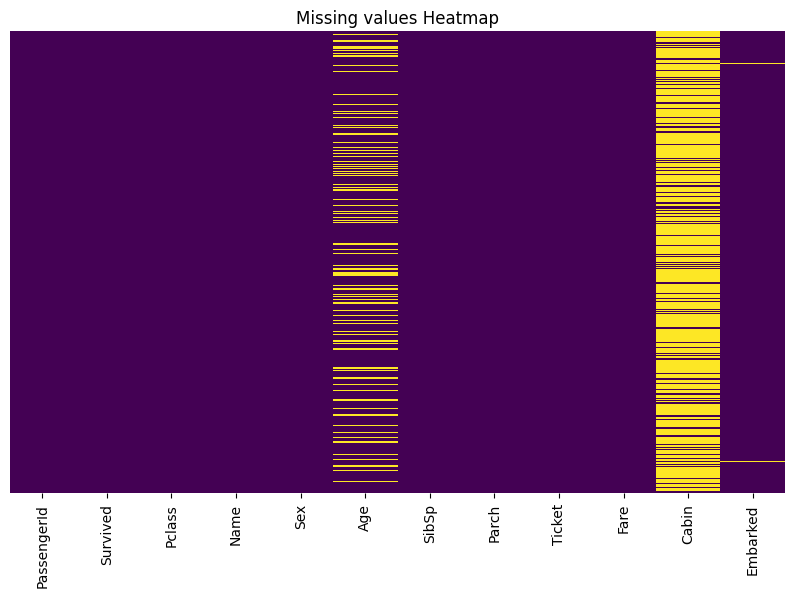

In [8]:
# visualize the missing values
plt.figure(figsize=(10,6))
sns.heatmap(train_data.isnull(), cmap='viridis',cbar=False,yticklabels=False)
plt.title("Missing values Heatmap")
plt.show()

In [9]:
# Handling missing values


In [10]:
# 1. Age: fill missing values with median
train_data['Age'] = train_data.Age.fillna(train_data.Age.median())

In [11]:
# 2. Cabin: Drop the columns -- has many null values
train_data.drop('Cabin', axis='columns', inplace=True)

In [12]:
# 3. Embarked : Fill the missing values with the most common values
most_common_value = train_data.Embarked.mode()[0]
most_common_value

'S'

In [13]:
train_data['Embarked']= train_data.Embarked.fillna(most_common_value)

In [14]:
# check missing values are handled
train_data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [15]:
# working on survived column
train_data.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [16]:
# Calculate the percentage of survived people
survival_percent = (train_data.Survived.sum() / len(train_data)) *100
survival_percent

np.float64(38.38383838383838)

In [17]:
print(f"Percentage of survival people is: {survival_percent:.2f}%")

Percentage of survival people is: 38.38%


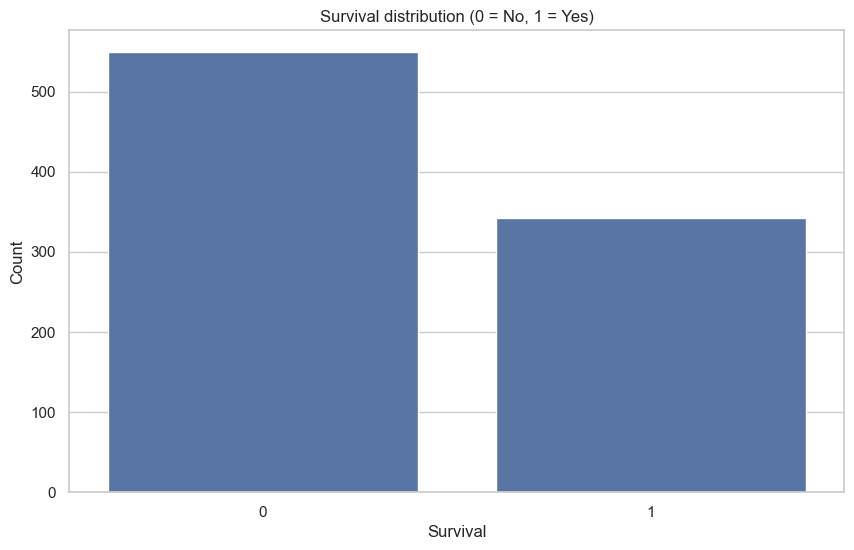

In [18]:
# visualize the survival rate
# set style for the plots
sns.set(style='whitegrid')

plt.figure(figsize=(10,6))
sns.countplot(x='Survived', data=train_data)
plt.title("Survival distribution (0 = No, 1 = Yes)")
plt.xlabel("Survival")
plt.ylabel("Count")
plt.show()

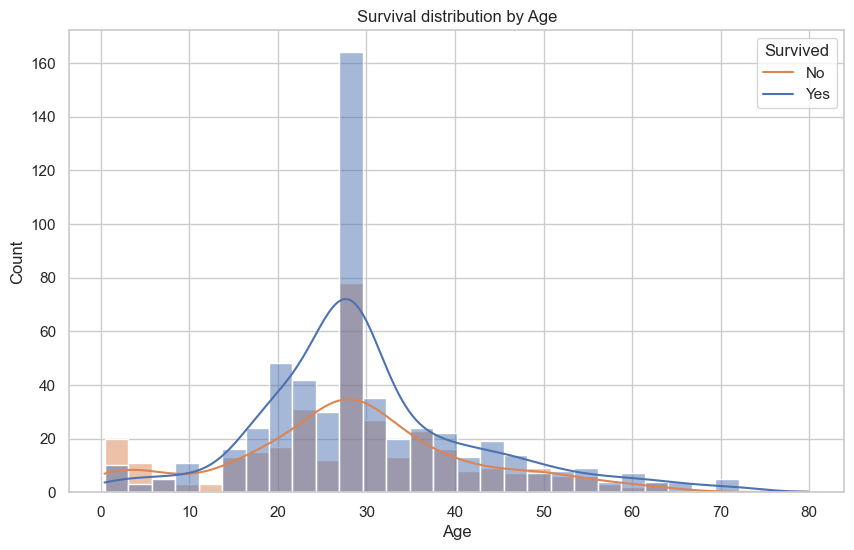

In [19]:
# visualize the survival rate by age
plt.figure(figsize=(10,6))
sns.histplot(data=train_data, x='Age', hue='Survived', kde=True,)
plt.title("Survival distribution by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()

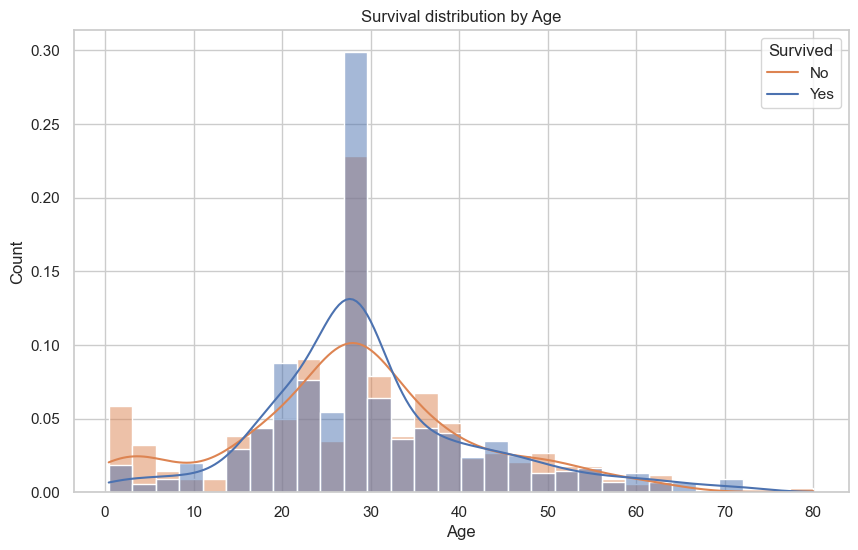

In [20]:
# visualize the survival rate by age
plt.figure(figsize=(10,6))
sns.histplot(data=train_data, x='Age', hue='Survived', kde=True, stat='probability', common_norm=False)
plt.title("Survival distribution by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()

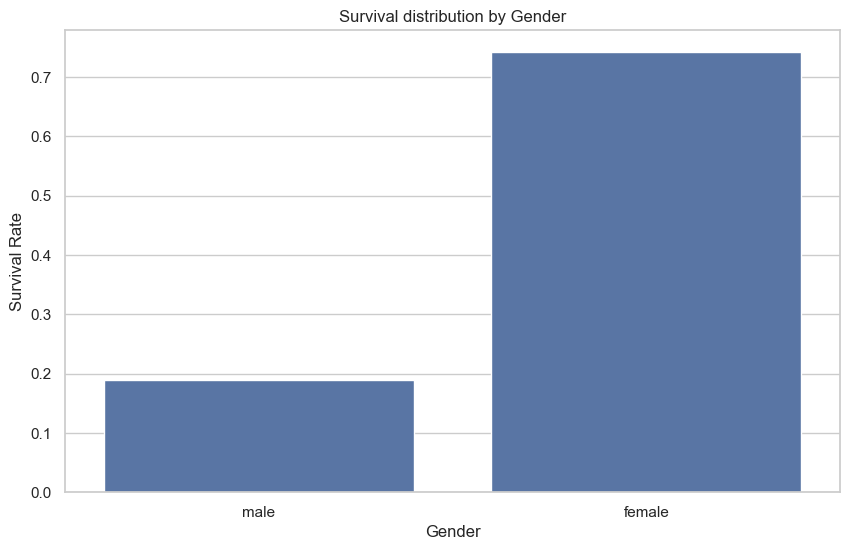

In [21]:
# visualize survived rate by Gender
plt.figure(figsize=(10,6))
sns.barplot(data=train_data, x='Sex', y='Survived', errorbar=None)
plt.title("Survival distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

In [22]:
train_data_copy = train_data.copy()

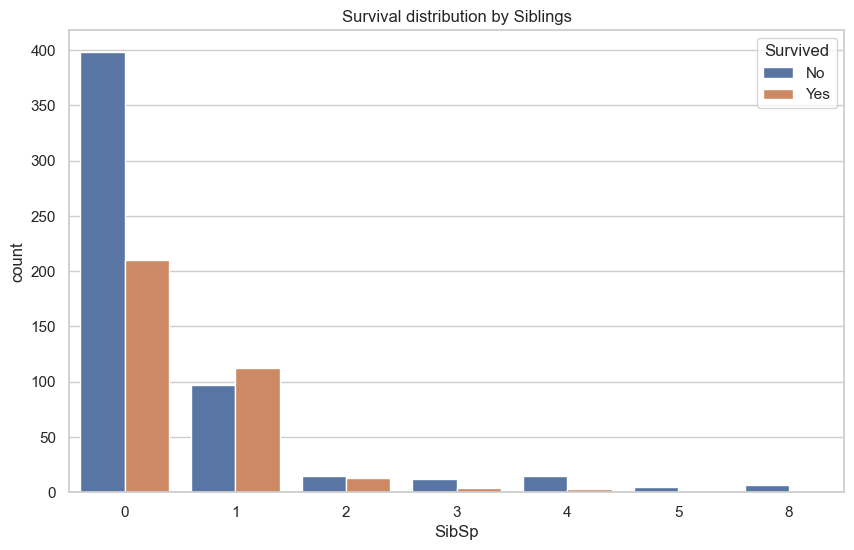

In [23]:
# visualize survival rate by number of siblings
plt.figure(figsize=(10,6))
sns.countplot(data=train_data_copy, x='SibSp', hue='Survived')
plt.title("Survival distribution by Siblings")
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()

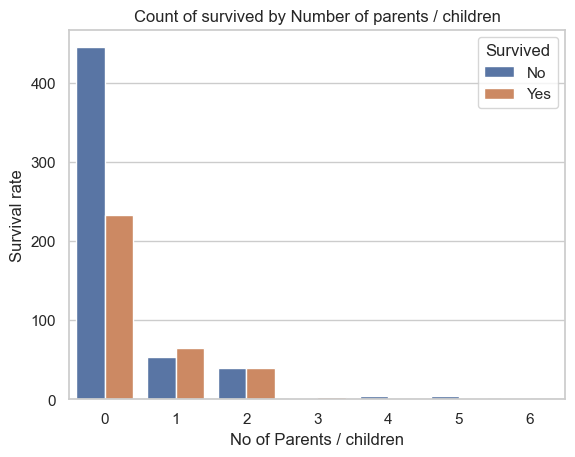

In [24]:
# Explore demographic characteristics
sns.countplot(data=train_data_copy, x='Parch', hue='Survived')
plt.title("Count of survived by Number of parents / children")
plt.xlabel("No of Parents / children")
plt.ylabel("Survival rate")
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()

Text(0, 0.5, 'Survival Rate')

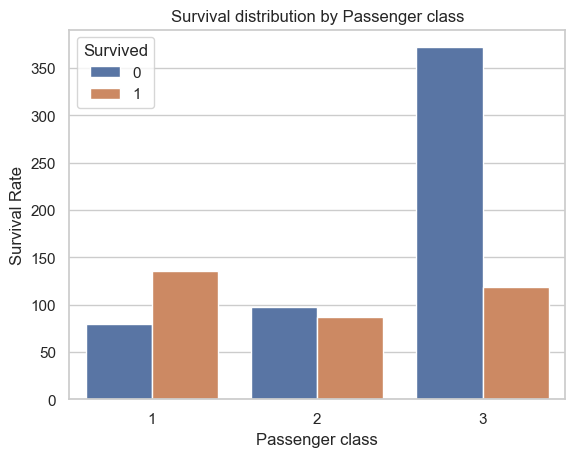

In [25]:
# visualize the survival rate by passenger class
sns.countplot(data=train_data_copy, x='Pclass', hue='Survived')
plt.title("Survival distribution by Passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival Rate")

In [26]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.0 KB


<Axes: xlabel='Pclass', ylabel='Survived'>

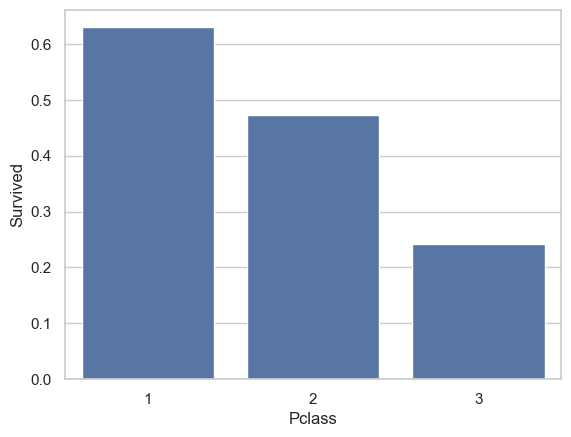

In [27]:
# visualize the survival rate proportion by passenger class
sns.barplot(data=train_data, x='Pclass', y='Survived', errorbar=None)

In [28]:
# calculate the average fare for surviver and non survivor
avg_fare = train_data.groupby('Survived')['Fare'].mean()
avg_fare

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

In [29]:
print(f"Average fare for Non survivers:{avg_fare[0]:.2f}")
print(f"Average fare for  survivers:", avg_fare[1])



Average fare for Non survivers:22.12
Average fare for  survivers: 48.39540760233918


In [30]:
# create cross tabulation of Embarked and survived
embarked_survival = pd.crosstab(train_data['Embarked'], train_data['Survived'], margins=True, margins_name='Total')
embarked_survival

Survived,0,1,Total
Embarked,,,
C,75,93,168
Q,47,30,77
S,427,219,646
Total,549,342,891


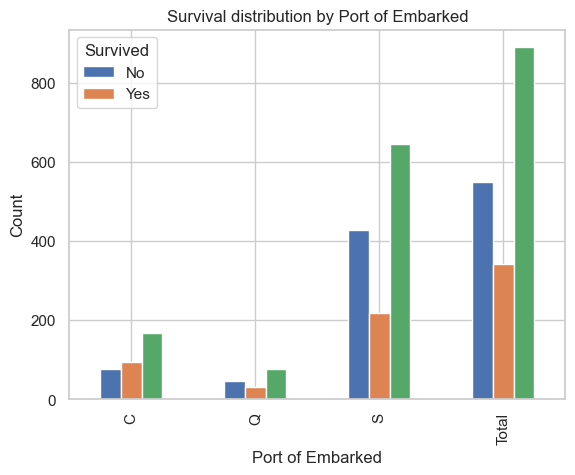

In [31]:

#plot the bar
embarked_survival.plot(kind='bar')
plt.title("Survival distribution by Port of Embarked")
plt.xlabel("Port of Embarked")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()

In [32]:
# Calculate survival rate (percentage) for each combination of "Embarked" and "Survived"
embarked_survival_rate = pd.crosstab(index=train_data['Embarked'], columns=train_data['Survived'], normalize='index') * 100

# Display the table
embarked_survival_rate

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.099071,33.900929


In [33]:
test_data.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [34]:
train_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [35]:
train_data = train_data.drop('Name', axis=1)

In [36]:
train_data = train_data.drop(['PassengerId', 'Ticket'], axis=1)

In [37]:
# perform one-hot encoding on categorical columns
train_data = pd.get_dummies(train_data, columns=['Pclass','Sex','Embarked'],drop_first=True)
train_data.head(2)

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,False,True,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False


In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
# select numerical columns
numerical_cols = ['Age','SibSp','Parch','Fare']
scaler = MinMaxScaler()
train_data[numerical_cols] = scaler.fit_transform(train_data[numerical_cols])


In [40]:
train_data.head(2)

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,0.271174,0.125,0.0,0.014151,False,True,True,False,True
1,1,0.472229,0.125,0.0,0.139136,False,False,False,False,False


In [41]:
# split the data into features X, and target y
X = train_data.drop('Survived', axis=1)
X.head(2)

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0.271174,0.125,0.0,0.014151,False,True,True,False,True
1,0.472229,0.125,0.0,0.139136,False,False,False,False,False


In [42]:
y = train_data.Survived
y.head(2)

0    0
1    1
Name: Survived, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [51]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [50]:
models = {
    'LogisticRegression': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'SVC': SVC(),
    
}

In [52]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    print("Model Name: ", model)
    print("Accuracy Score: ", acc)
    print("------------")

Model Name:  LogisticRegression()
Accuracy Score:  0.7988826815642458
------------
Model Name:  RandomForestClassifier()
Accuracy Score:  0.7988826815642458
------------
Model Name:  GradientBoostingClassifier()
Accuracy Score:  0.8156424581005587
------------
Model Name:  SVC()
Accuracy Score:  0.7932960893854749
------------


In [55]:
# use : Model Name:  GradientBoostingClassifier()
gr = GradientBoostingClassifier()
gr.fit(X_train,y_train)
print(accuracy_score(y_test, gr.predict(X_test)))

0.8156424581005587


In [340]:
test_data.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [341]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [342]:
# drop 
test_data = test_data.drop(['Name','PassengerId','Ticket'], axis=1)

In [343]:
test_data.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,34.5,0,0,7.8292,NaN,Q
1,3,female,47.0,1,0,7.0000,NaN,S


In [367]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Pclass    418 non-null    int64 
 1   Sex       418 non-null    str   
 2   Age       418 non-null    object
 3   SibSp     418 non-null    int64 
 4   Parch     418 non-null    int64 
 5   Fare      418 non-null    object
 6   Embarked  418 non-null    str   
dtypes: int64(3), object(2), str(2)
memory usage: 25.3+ KB


In [368]:
test_data.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [369]:
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median)

In [370]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median)

In [371]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Pclass    418 non-null    int64 
 1   Sex       418 non-null    str   
 2   Age       418 non-null    object
 3   SibSp     418 non-null    int64 
 4   Parch     418 non-null    int64 
 5   Fare      418 non-null    object
 6   Embarked  418 non-null    str   
dtypes: int64(3), object(2), str(2)
memory usage: 25.3+ KB


In [372]:
test_data.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [350]:
test_data.drop('Cabin', axis=1, inplace=True)

In [373]:
numerical_cols

['Age', 'SibSp', 'Parch', 'Fare']

In [374]:
test_data.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0,S


In [375]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Pclass    418 non-null    int64 
 1   Sex       418 non-null    str   
 2   Age       418 non-null    object
 3   SibSp     418 non-null    int64 
 4   Parch     418 non-null    int64 
 5   Fare      418 non-null    object
 6   Embarked  418 non-null    str   
dtypes: int64(3), object(2), str(2)
memory usage: 25.3+ KB


In [376]:
new_test = test_data.copy()


In [377]:
new_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Pclass    418 non-null    int64 
 1   Sex       418 non-null    str   
 2   Age       418 non-null    object
 3   SibSp     418 non-null    int64 
 4   Parch     418 non-null    int64 
 5   Fare      418 non-null    object
 6   Embarked  418 non-null    str   
dtypes: int64(3), object(2), str(2)
memory usage: 25.3+ KB


In [378]:
new_test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [379]:
# test_data['Age'] = test_data['Age'].astype(float)
# test_data['Age'] = pd.to_numeric(test_data['Age'])

new_test['Age'] = pd.to_numeric(new_test['Age'], errors='coerce')

In [380]:
new_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    str    
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    object 
 6   Embarked  418 non-null    str    
dtypes: float64(1), int64(3), object(1), str(2)
memory usage: 25.3+ KB


In [381]:
new_test['Fare'] = pd.to_numeric(new_test['Fare'], errors='coerce')

In [382]:
new_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    str    
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    str    
dtypes: float64(2), int64(3), str(2)
memory usage: 25.3 KB


In [383]:
new_test.isna().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [385]:
new_test.dropna(inplace=True)

In [386]:
new_test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [387]:
new_test[numerical_cols] = scaler.fit_transform(new_test[numerical_cols])
new_test.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.452723,0.000,0.0,0.015282,Q
1,3,female,0.617566,0.125,0.0,0.013663,S


In [388]:
new_test = pd.get_dummies(new_test, columns=['Pclass','Sex','Embarked'], drop_first=True)
new_test.head()

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0.452723,0.000,0.000000,0.015282,False,True,True,True,False
1,0.617566,0.125,0.000000,0.013663,False,True,False,False,True
2,0.815377,0.000,0.000000,0.018909,True,False,True,True,False
3,0.353818,0.000,0.000000,0.016908,False,True,True,False,True
4,0.287881,0.125,0.166667,0.023984,False,True,False,False,True


In [389]:
# test_data with model 
gr.predict(new_test)

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,

In [390]:
new_test['survived'] = gr.predict(new_test)
new_test

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,survived
0,0.452723,0.000,0.000000,0.015282,False,True,True,True,False,0
1,0.617566,0.125,0.000000,0.013663,False,True,False,False,True,1
2,0.815377,0.000,0.000000,0.018909,True,False,True,True,False,0
3,0.353818,0.000,0.000000,0.016908,False,True,True,False,True,0
4,0.287881,0.125,0.166667,0.023984,False,True,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...
409,0.037320,0.125,0.166667,0.026887,False,True,False,False,True,1
411,0.485692,0.125,0.000000,0.175668,False,False,False,True,False,1
412,0.367005,0.000,0.000000,0.015176,False,True,False,False,True,0
414,0.512066,0.000,0.000000,0.212559,False,False,False,False,False,1


In [391]:
new_test.groupby('survived').value_counts()

survived  Age       SibSp  Parch  Fare      Pclass_2  Pclass_3  Sex_male  Embarked_Q  Embarked_S
0         0.340630  0.000  0.0    0.025374  True      False     True      False       True          3
          0.353818  0.000  0.0    0.016908  False     True      True      False       True          2
          0.393380  0.000  0.0    0.025374  True      False     True      False       True          2
          0.340630  0.000  0.0    0.015176  False     True      True      False       True          2
          0.551629  0.000  0.0    0.051822  False     False     True      False       True          2
                                                                                                   ..
1         0.235131  0.000  0.0    0.014110  False     True      False     False       False         1
          0.301068  0.125  0.0    0.160574  False     False     False     False       True          1
          0.617566  0.125  0.0    0.119406  False     False     False     False       T